# FNO Channel Design v3 — Fixed

## What the visualisation revealed

| Channel | Previous approach | Problem | Fix |
|---|---|---|---|
| Ch1 | irfft2(log\|FFT\|²) | Artifact wavy pattern, identical across classes | **Bandpass energy map** — filter image into 3 freq bands, show which band has most energy |
| Ch2 | irfft2(phase-only spectrum) | Pure noise, no structure | **Azimuthal asymmetry** — angular std at each radius ring |
| Ch3 | Radial deviation | ✅ Working perfectly | Keep as-is |

## New Ch1: Bandpass energy map
Split the frequency spectrum into low / mid / high bands.
Subhalo concentrates energy in mid-freq band (localized arc distortion).
Vortex redistributes to low-freq band (large-scale ring perturbation).
Map = ratio of mid-band to low-band energy → large where substructure is.

## New Ch2: Azimuthal asymmetry  
For each radial ring, compute the std of pixel values around the ring.
- no_sub: ring is uniform → low std everywhere
- subhalo: one bright spot breaks uniformity → high std at ring radius
- vortex: arc brightness varies → high std across multiple rings
This is the angular complement to Ch3's radial complement.

In [1]:
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt

class LensDatasetFNO(Dataset):
    """
    FNO-optimised 4-channel input (v3 — fixed):

    Ch 0 — Raw image              (spatial flux)
    Ch 1 — Bandpass energy map    (mid/low freq energy ratio — substructure signature)
    Ch 2 — Azimuthal asymmetry    (angular std per radial ring — symmetry-breaking)
    Ch 3 — Radial symmetry dev    (radial deviation — confirmed working)
    """

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.paths, self.labels = [], []
        self.classes = sorted([d for d in os.listdir(root_dir)
                                if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        for cls in self.classes:
            for f in os.listdir(os.path.join(root_dir, cls)):
                if f.endswith(".npy"):
                    self.paths.append(os.path.join(root_dir, cls, f))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self): return len(self.paths)

    def bandpass_energy_map(self, img):
        """
        Ch 1: Spatial map of mid-frequency energy relative to low-frequency energy.

        Steps:
          1. Compute rfft2 of the image
          2. Create 3 radial frequency masks in Fourier space:
               low  : |k| < r1      (global ring shape)
               mid  : r1 <= |k| < r2 (arc-scale substructure)
               high : |k| >= r2     (noise — discarded)
          3. Reconstruct spatial images from each band via irfft2
          4. Return |mid_band| / (|low_band| + eps)

        Subhalo: bright localized spot in mid-band (localized arc distortion)
        Vortex : distributed perturbation shows in low-band ratio
        no_sub : near-uniform ratio (no excess mid-freq energy)
        """
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        ft = torch.fft.rfft2(img[0], norm="ortho")   # (H, W//2+1) complex

        # build radial frequency grid in rfft2 space
        fy = torch.fft.fftfreq(H)                    # (H,)
        fx = torch.fft.rfftfreq(W)                   # (W//2+1,)
        FY, FX = torch.meshgrid(fy, fx, indexing='ij')
        R = torch.sqrt(FY**2 + FX**2)                # (H, W//2+1)

        r1, r2 = 0.08, 0.25   # low < 0.08, mid 0.08-0.25, high > 0.25

        low_mask = (R < r1).float()
        mid_mask = ((R >= r1) & (R < r2)).float()

        low_spatial = torch.fft.irfft2(ft * low_mask, s=(H, W), norm="ortho").abs()
        mid_spatial = torch.fft.irfft2(ft * mid_mask, s=(H, W), norm="ortho").abs()

        ratio = mid_spatial / (low_spatial + eps)
        ratio = ratio.clamp(0, ratio.quantile(0.99))   # clip outliers
        ratio = (ratio - ratio.min()) / (ratio.max() - ratio.min() + eps)
        return ratio.unsqueeze(0)

    def azimuthal_asymmetry(self, img):
        """
        Ch 2: Angular standard deviation of intensity at each radial ring.

        For each pixel at radius r, compute std of all pixels at the same r.
        - no_sub  : smooth ring → uniform intensity around ring → low std
        - subhalo : one bright point on ring → high std at that ring radius
        - vortex  : arc brightness variation → elevated std across ring radii

        This is the ANGULAR complement to Ch3 (which measures radial deviation).
        Together Ch2+Ch3 fully decompose the 2D symmetry-breaking signal.
        """
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = W / 2.0, H / 2.0
        ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
        xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
        radii = torch.sqrt((xs - cx)**2 + (ys - cy)**2)

        n_bins  = 40
        r_max   = radii.max()
        bin_idx = (radii / (r_max + eps) * n_bins).long().clamp(0, n_bins - 1)

        I = img[0]
        asymmetry = torch.zeros_like(I)
        for b in range(n_bins):
            mask = (bin_idx == b)
            if mask.sum() > 1:
                ring_std = I[mask].std()
                asymmetry[mask] = ring_std

        return ((asymmetry - asymmetry.min()) /
                (asymmetry.max() - asymmetry.min() + eps)).unsqueeze(0)

    def radial_symmetry(self, img):
        """Ch 3: unchanged — confirmed working in visualisation."""
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = W / 2.0, H / 2.0
        ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
        xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
        radii = torch.sqrt((xs - cx)**2 + (ys - cy)**2)
        n_bins  = 30
        r_max   = radii.max()
        bin_idx = (radii / (r_max + eps) * n_bins).long().clamp(0, n_bins - 1)
        I = img[0]
        deviation = torch.zeros_like(I)
        for b in range(n_bins):
            mask = (bin_idx == b)
            if mask.sum() > 0:
                deviation[mask] = (I[mask] - I[mask].mean()).abs()
        return ((deviation - deviation.min()) /
                (deviation.max() - deviation.min() + eps)).unsqueeze(0)

    def __getitem__(self, idx):
        image = torch.tensor(np.load(self.paths[idx]), dtype=torch.float32)
        if image.ndim == 2: image = image.unsqueeze(0)
        combined = torch.cat([
            image,
            self.bandpass_energy_map(image),   # Ch1: fixed
            self.azimuthal_asymmetry(image),   # Ch2: fixed
            self.radial_symmetry(image),       # Ch3: unchanged
        ], dim=0)
        if self.transform: combined = self.transform(combined)
        return combined, self.labels[idx]


## Visualise — verify all channels are discriminative

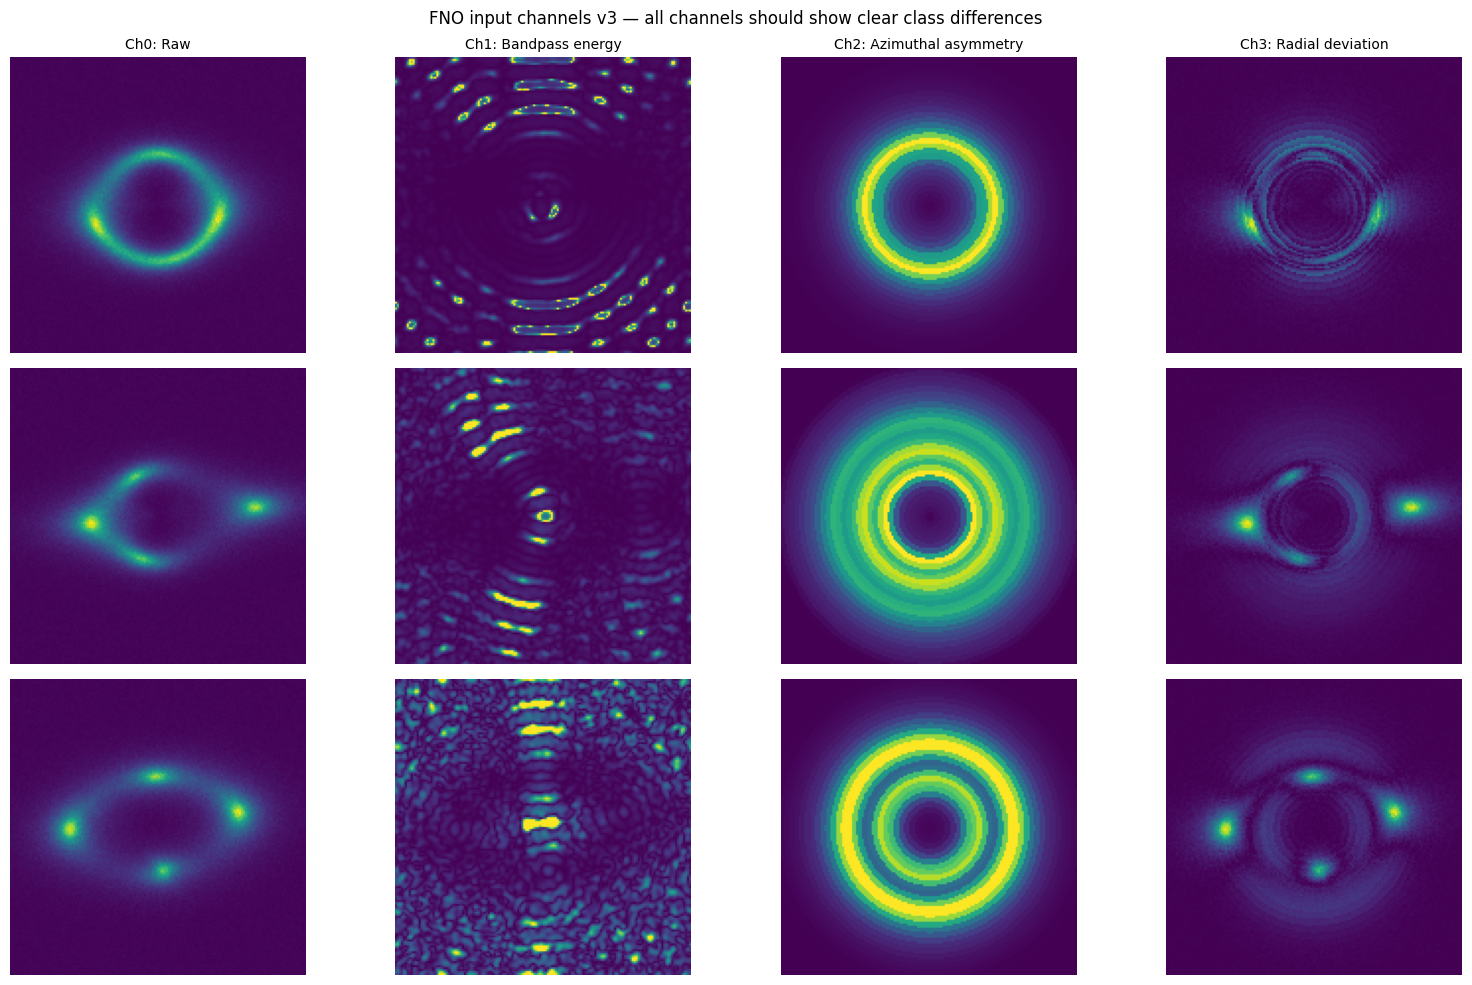

Expected:
Ch1: no_sub=uniform low ratio | subhalo=bright localised spot | vortex=distributed bright region
Ch2: no_sub=uniform low std   | subhalo=bright ring at subhalo radius | vortex=bright multiple rings
Ch3: no_sub=near zero         | subhalo=localised bright spot | vortex=arc bright regions


In [2]:
dataset_viz = LensDatasetFNO("dataset/train")
class_names = ['no_sub', 'subhalo', 'vortex']
ch_names    = ['Ch0: Raw', 'Ch1: Bandpass energy', 'Ch2: Azimuthal asymmetry', 'Ch3: Radial deviation']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for class_idx in range(3):
    idx = dataset_viz.labels.index(class_idx)
    img, _ = dataset_viz[idx]

    for ch in range(4):
        ax = axes[class_idx][ch]
        ax.imshow(img[ch].numpy(), cmap='viridis')
        if class_idx == 0: ax.set_title(ch_names[ch], fontsize=10)
        if ch == 0:        ax.set_ylabel(class_names[class_idx], fontsize=11)
        ax.axis('off')

plt.suptitle('FNO input channels v3 — all channels should show clear class differences', fontsize=12)
plt.tight_layout()
plt.show()

print("Expected:")
print("Ch1: no_sub=uniform low ratio | subhalo=bright localised spot | vortex=distributed bright region")
print("Ch2: no_sub=uniform low std   | subhalo=bright ring at subhalo radius | vortex=bright multiple rings")
print("Ch3: no_sub=near zero         | subhalo=localised bright spot | vortex=arc bright regions")


## Compute stats and build loaders

In [ ]:
def compute_channel_stats(dataset, n_channels=4):
    s1 = torch.zeros(n_channels); s2 = torch.zeros(n_channels); n = 0
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
    for imgs, _ in loader:
        s1 += imgs.sum(dim=[0,2,3])
        s2 += (imgs**2).sum(dim=[0,2,3])
        n  += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]
    mean = s1 / n
    std  = torch.sqrt((s2/n - mean**2).clamp(min=0)).clamp(min=0.0005)
    return mean.tolist(), std.tolist()

train_ds_raw = LensDatasetFNO("dataset/train")
MEAN_FNO, STD_FNO = compute_channel_stats(train_ds_raw, n_channels=4)
print("Channel means:", [f'{m:.4f}' for m in MEAN_FNO])
print("Channel stds :", [f'{s:.4f}' for s in STD_FNO])

IMG_SIZE = 150

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180, fill=0),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), fill=0),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=MEAN_FNO, std=STD_FNO)
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=MEAN_FNO, std=STD_FNO)
])

train_dataset = LensDatasetFNO("dataset/train", transform=train_transform)
val_dataset   = LensDatasetFNO("dataset/val",   transform=val_transform)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"\nInput shape: {train_dataset[0][0].shape}")   # (4, 150, 150)
